
1.	Import the attached Indian_food.csv file in Jupyter notebook and perform following data cleaning operations through operations using Pandas and visualizations using Matplotlib, Seaborn and Plotly
# New Section

In [292]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [293]:
sns.__version__

'0.13.2'

In [294]:
matplotlib.__version__

'3.10.0'

In [295]:
pd.__version__

'2.2.2'

In [296]:
np.__version__

'1.26.4'

In [297]:
indian_food=pd.read_excel("Indian_food.xlsm")

In [298]:
indian_food.head(5)

,Name,Ingredients,Diet,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,40,sweet,dessert,West Bengal,East


In [299]:
indian_food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            253 non-null    object
 1   Ingredients     253 non-null    object
 2   Diet            253 non-null    object
 3   cook_time       253 non-null    int64 
 4   flavor_profile  253 non-null    object
 5   course          253 non-null    object
 6   state           253 non-null    object
 7   region          253 non-null    object
dtypes: int64(1), object(7)
memory usage: 15.9+ KB


In [300]:
indian_food.describe(include="all")

,Name,Ingredients,Diet,cook_time,flavor_profile,course,state,region
count,253,253,253,253.000000,253,253,253,253
unique,253,250,2,NaN,5,4,25,7
top,Balu shahi,"Gram flour, ghee, sugar",vegetarian,NaN,spicy,main course,Gujarat,West
freq,1,2,224,NaN,133,127,35,74
mean,NaN,NaN,NaN,37.604743,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,47.515765,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,45.000000,NaN,NaN,NaN,NaN


In [301]:
indian_food.isna().sum()

,0
Name,0
Ingredients,0
Diet,0
cook_time,0
flavor_profile,0
course,0
state,0
region,0


## Data Cleaning

a)	In the state column, replace the -1 with the mode of state column.



In [302]:
mode=indian_food.state.mode()[0]
mode

'Gujarat'

In [303]:
indian_food.loc[indian_food["state"]==-1,"state"]=mode#replcing the value with mode of state column

In [304]:
indian_food["state"].unique()

array(['West Bengal', 'Rajasthan', 'Punjab', 'Uttar Pradesh', 'Gujarat',
       'Odisha', 'Maharashtra', 'Uttarakhand', 'Assam', 'Bihar',
       'Andhra Pradesh', 'Karnataka', 'Telangana', 'Kerala', 'Tamil Nadu',
       'Tripura', 'Manipur', 'Nagaland', 'NCT of Delhi',
       'Jammu & Kashmir', 'Chhattisgarh', 'Haryana', 'Madhya Pradesh',
       'Goa'], dtype=object)

In [305]:
indian_food[indian_food["state"]==-1]#checking if all the values have been replaced

,Name,Ingredients,Diet,cook_time,flavor_profile,course,state,region


b)	Whatever the state you got in previous question, fill the corresponding region in the region column.

In [ ]:
indian_food[indian_food["state"]=="Gujarat"]["region"]#gujarat corresponding region values is west

In [311]:

indian_food.loc[indian_food["region"] == -1, "region"] = "West"

#all states having value Gujarat have corressponding region value West.

In [312]:
indian_food[indian_food["state"]=="Gujarat"]["region"]

,region
7,West
9,West
10,West
12,West
56,West
58,West
94,West
96,West
98,West
109,West


c)	Replace the -1 with mean for cook time variable.

In [313]:
mean=indian_food["cook_time"].mean().round(2)
mean

37.6

In [314]:
indian_food["cook_time"].unique()

array([ 25,  30,  60,  40,  50,  20,   5,  45, 120,  35,  90,  75,  15,
       720,  55,  -1,  10,   2,   6])

In [315]:
indian_food.loc[indian_food["cook_time"]==-1,"cook_time"]=mean

<ipython-input-315-90839dd7483c>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '37.6' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  indian_food.loc[indian_food["cook_time"]==-1,"cook_time"]=mean


In [316]:
indian_food["cook_time"].unique()

array([ 25. ,  30. ,  60. ,  40. ,  50. ,  20. ,   5. ,  45. , 120. ,
        35. ,  90. ,  75. ,  15. , 720. ,  55. ,  37.6,  10. ,   2. ,
         6. ])

d)	Most preferred flavours by number of customers using pie chart.

In [317]:
customer_count=indian_food["flavor_profile"].value_counts()
customer_count

,count
flavor_profile,
spicy,133
sweet,90
salty,14
chilli,10
sour,6


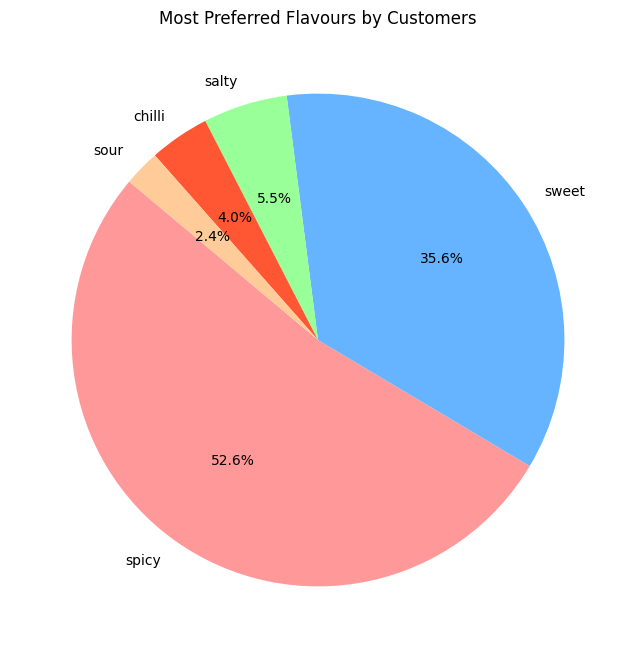

In [318]:
plt.figure(figsize=(8, 8))
plt.pie(customer_count, labels=customer_count.index, autopct='%1.1f%%', startangle=140, colors=["#ff9999","#66b3ff","#99ff99","#ff5733","#ffcc99"])
plt.title("Most Preferred Flavours by Customers")
plt.show()

e)	Most requested course by customers using Bar chart. Print the labels also on the top of each bar. Then sort the bar chart in descending order.

In [319]:
customer_count=indian_food["course"].value_counts().sort_values(ascending=False)
customer_count

,count
course,
main course,127
dessert,85
snack,39
starter,2


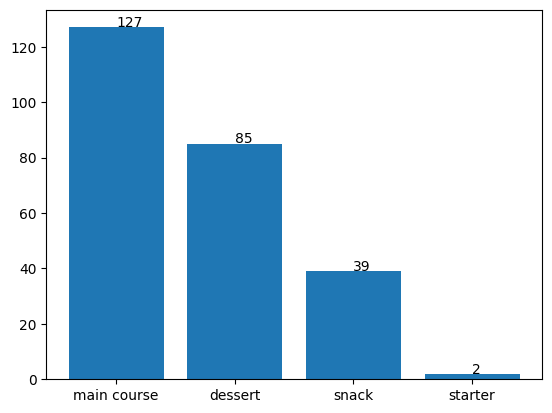

In [320]:
plt.bar(x=customer_count.index,height=customer_count)
for i,j in customer_count.items():
  plt.text(i,j+0.2,j)


f)	Comparison between Vegetarians and Non-Veg orders in each region. Hint: You can use stacked/grouped bar chart for comparison.



In [359]:
x = np.sort(indian_food["region"].unique(),)
y1=indian_food[indian_food["Diet"]=="vegetarian"].groupby("region")["Diet"].count().sort_index(ascending=True)
y2=indian_food[indian_food["Diet"]=="non vegetarian"].groupby("region")["Diet"].count().sort_index(ascending=True)
y1 = y1.reindex(x, fill_value=0)
y2 = y2.reindex(x, fill_value=0)
print(y2)
print(y1)
print(x)

region
Central        0
East           5
North          5
North East    13
South          3
West           3
Name: Diet, dtype: int64
region
Central        3
East          26
North         44
North East    12
South         46
West          93
Name: Diet, dtype: int64
['Central' 'East' 'North' 'North East' 'South' 'West']


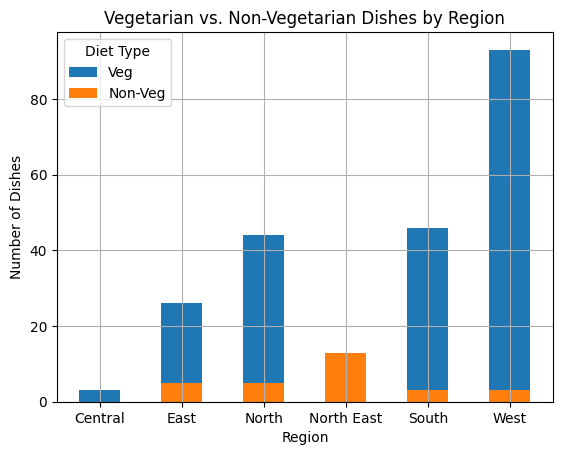

In [380]:

plt.bar(x,y1,label="Veg",width=0.5)
plt.bar(x,y2,label="Non-Veg",width=0.5)
plt.grid(True)
plt.xlabel("Region")
plt.ylabel("Number of Dishes")
plt.title("Vegetarian vs. Non-Vegetarian Dishes by Region")
plt.xticks(x, y1.index)
plt.legend(title="Diet Type", loc="upper left")


             str(int(bar.get_height())), ha='center', fontsize=12, fontweight="bold")



g)	Create the box plot for Order cooking time to see the distribution. Also check if there are any outliers in this column

{'whiskers': [<matplotlib.lines.Line2D at 0x7f255972a150>,
 'caps': [<matplotlib.lines.Line2D at 0x7f255972bc90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f25592da290>],
 'medians': [<matplotlib.lines.Line2D at 0x7f2559372450>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f2559370510>],
 'means': []}

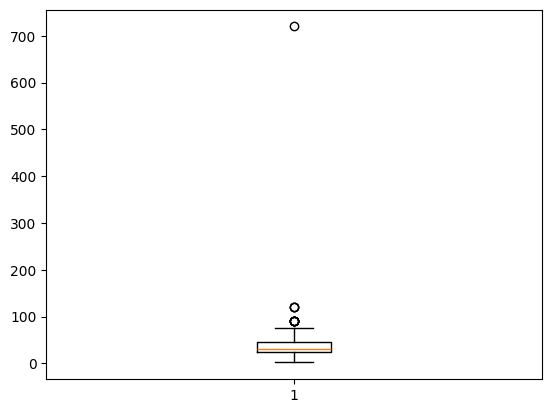

In [381]:
plt.boxplot(indian_food["cook_time"])


In [384]:
q1=indian_food["cook_time"].quantile(0.25)
q3=indian_food["cook_time"].quantile(0.75)
IQR=q3-q1
IQR #IQR*1.5 will be used to define lower and upper range

20.0

In [391]:
lower_range=q1-IQR*1.5
upper_range=q3+IQR*1.5

outliers=indian_food[(indian_food["cook_time"]<lower_range) | (indian_food["cook_time"]>upper_range) ]

In [392]:
outliers

,Name,Ingredients,Diet,cook_time,flavor_profile,course,state,region
27,Malapua,"Yoghurt, refined flour, ghee, fennel seeds",vegetarian,120.0,sweet,dessert,Bihar,North
34,Rasgulla,"Chhena, sugar, cardamom",vegetarian,90.0,sweet,dessert,West Bengal,East
62,Shrikhand,"Curd, sugar, saffron, cardamom",vegetarian,720.0,sweet,dessert,Maharashtra,West
75,Biryani,"Chicken thighs, basmati rice, star anise, swee...",non vegetarian,120.0,spicy,main course,Telangana,South
83,Daal baati churma,"Moong dal, masoor dal, chana dal, wheat flour,...",vegetarian,90.0,spicy,main course,Rajasthan,West
114,Pindi chana,"Fennel, tea bags, tomato, kasuri methi, cinnamon",vegetarian,120.0,spicy,main course,Punjab,North
115,Rajma chaval,"Red kidney beans, garam masala powder, ginger,...",vegetarian,90.0,spicy,main course,Gujarat,West
128,Dosa,"Chana dal, urad dal, whole urad dal, blend ric...",vegetarian,90.0,spicy,snack,Gujarat,West
130,Idli,"Split urad dal, urad dal, idli rice, thick poh...",vegetarian,90.0,spicy,snack,Gujarat,West
142,Kuzhakkattai,"Sesame oil, raw rice, jaggery, grated coconut",vegetarian,90.0,spicy,main course,Tamil Nadu,South


# 2.	Import the attached Billionaires_Stats.csv file in Jupyter notebook and perform following operations using Pandas and Data visualization

In [433]:
billionaires=pd.read_excel("Billionaires.xlsm")
billionaires.head(5)

,finalWorth,category,personName,age,country,city,gender,birthYear,birthMonth,birthDay
0,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,M,1949.0,3.0,5.0
1,180000,Automotive,Elon Musk,51.0,United States,Austin,M,1971.0,6.0,28.0
2,114000,Technology,Jeff Bezos,59.0,United States,Medina,M,1964.0,1.0,12.0
3,107000,Technology,Larry Ellison,78.0,United States,Lanai,M,1944.0,8.0,17.0
4,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,M,1930.0,8.0,30.0


In [434]:
billionaires.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   finalWorth  2640 non-null   int64  
 1   category    2640 non-null   object 
 2   personName  2640 non-null   object 
 3   age         2575 non-null   float64
 4   country     2602 non-null   object 
 5   city        2568 non-null   object 
 6   gender      2640 non-null   object 
 7   birthYear   2564 non-null   float64
 8   birthMonth  2564 non-null   float64
 9   birthDay    2564 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 206.4+ KB


In [435]:
billionaires.describe(include="all")

,finalWorth,category,personName,age,country,city,gender,birthYear,birthMonth,birthDay
count,2640.000000,2640,2640,2575.000000,2602,2568,2640,2564.000000,2564.000000,2564.000000
unique,NaN,18,2638,NaN,78,741,2,NaN,NaN,NaN
top,NaN,Finance & Investments,Wang Yanqing & family,NaN,United States,New York,M,NaN,NaN,NaN
freq,NaN,372,2,NaN,754,99,2303,NaN,NaN,NaN
mean,4623.787879,NaN,NaN,65.140194,NaN,NaN,NaN,1957.183307,5.740250,12.099844
std,9834.240939,NaN,NaN,13.258098,NaN,NaN,NaN,13.282516,3.710085,9.918876
min,1000.000000,NaN,NaN,18.000000,NaN,NaN,NaN,1921.000000,1.000000,1.000000
25%,1500.000000,NaN,NaN,56.000000,NaN,NaN,NaN,1948.000000,2.000000,1.000000
50%,2300.000000,NaN,NaN,65.000000,NaN,NaN,NaN,1957.000000,6.000000,11.000000
75%,4200.000000,NaN,NaN,75.000000,NaN,NaN,NaN,1966.000000,9.000000,21.000000


In [436]:
billionaires.isna().sum()#checking for null values

,0
finalWorth,0
category,0
personName,0
age,65
country,38
city,72
gender,0
birthYear,76
birthMonth,76
birthDay,76


In [437]:
billionaires.dropna(subset=["age","birthYear", "birthMonth", "birthDay"],how="all",inplace=True)

In [439]:
billionaires["birthMonth"].fillna(1,inplace=True)
billionaires["birthDay"].fillna(1,inplace=True)

<ipython-input-439-68939a39177e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  billionaires["birthMonth"].fillna(1,inplace=True)
<ipython-input-439-68939a39177e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [444]:
billionaires["birthYear"].fillna(2022-billionaires["age"],inplace=True)

<ipython-input-444-43f837f6a9a1>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  billionaires["birthYear"].fillna(2022-billionaires["age"],inplace=True)


In [447]:
billionaires["age"].fillna(2022-billionaires["birthYear"],inplace=True)

<ipython-input-447-2ea149ec0869>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  billionaires["age"].fillna(2022-billionaires["birthYear"],inplace=True)


In [457]:
billionaires.dropna(subset=["country", "city"], inplace=True,how="all")

In [459]:
billionaires["city"].fillna(method="ffill",inplace=True)

<ipython-input-459-f6dd501a9799>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  billionaires["city"].fillna(method="ffill",inplace=True)
<ipython-input-459-f6dd501a9799>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  billionaires["city"].fillna(method="ffill",inplace=True)


In [460]:
billionaires.isna().sum()

,0
finalWorth,0
category,0
personName,0
age,0
country,0
city,0
gender,0
birthYear,0
birthMonth,0
birthDay,0


a)	Create a dataframe which will have the billionaires whose age is greater than or equal to 30. Then create a scatter plot to show the relationship between age and net worth.

In [466]:
age_30=billionaires.loc[billionaires["age"]>=30,["age","finalWorth"]]
age_30

,age,finalWorth
0,74.0,211000
1,51.0,180000
2,59.0,114000
3,78.0,107000
4,92.0,106000
...,...,...
2635,51.0,1000
2636,80.0,1000
2637,60.0,1000
2638,71.0,1000


Text(0, 0.5, 'Age')

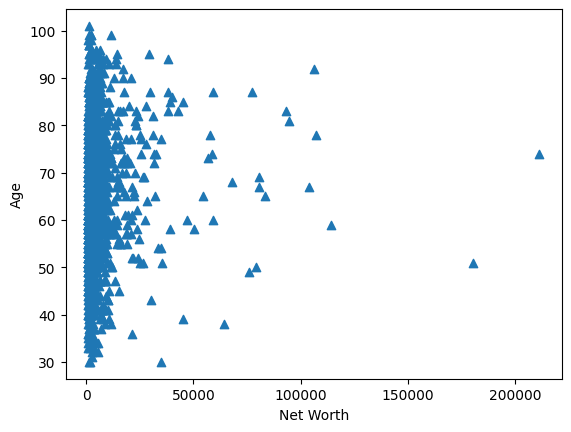

In [467]:
plt.scatter(age_30.loc[:,"finalWorth"],age_30.loc[:,"age"],marker="^")
plt.xlabel("Net Worth")
plt.ylabel("Age")

b)	Create a histogram to see the distribution of ages.

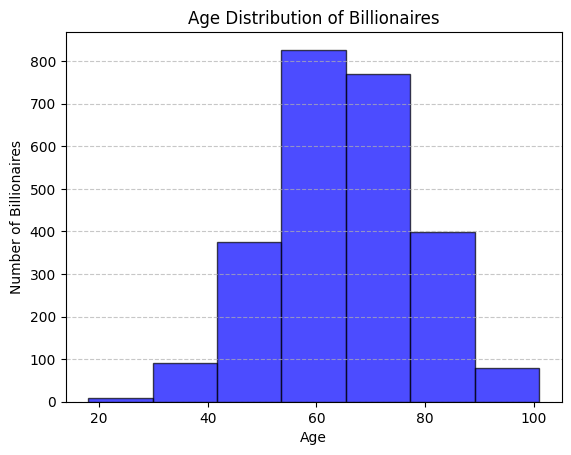

In [473]:
plt.hist(billionaires.loc[:,"age"],bins=7,color="blue", edgecolor="black", alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Number of Billionaires")
plt.title("Age Distribution of Billionaires")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

c)	Create a heatmap and see the correlation between all the numeric variables. Print the correlation value also in the heatmap.

<Axes: >

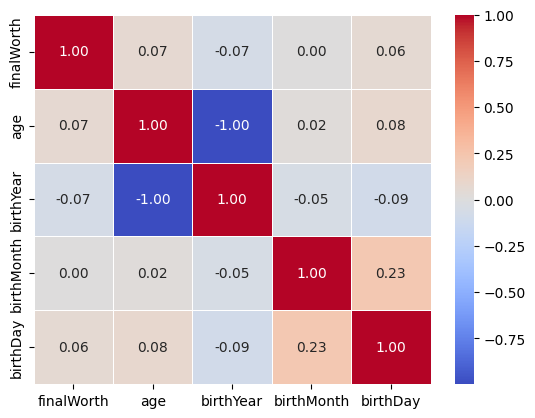

In [479]:
numeric_columns = billionaires.select_dtypes(include=["int64", "float64"])
heatmap=sns.heatmap(numeric_columns.corr(),cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
heatmap


d)	Save the figure in your pwd generated through previous question

In [480]:
heatmap.figure.savefig("heatmap_seaborn.png", dpi=300, bbox_inches="tight")

# 3.	Name any 5 types of charts you are familiar with (using any of 3 libraries).
# Write the sample code also to create those charts using random data.

range(0, 20)


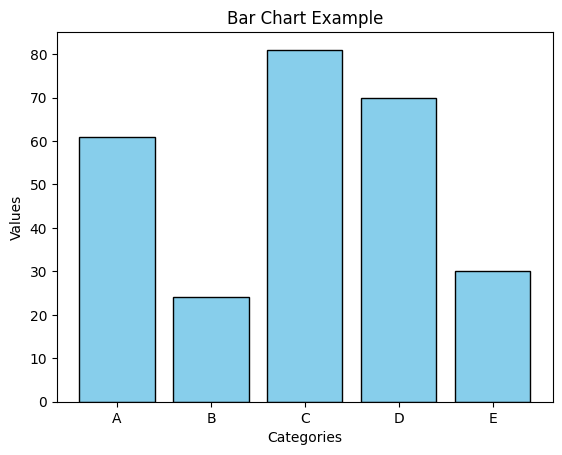

In [517]:
#1 bar chart
import numpy as np
import matplotlib.pyplot as plt

# Generate random data
np.random.seed(42)
categories = ['A', 'B', 'C', 'D', 'E']
values = np.random.randint(10, 100, size=5)

# Create bar chart
plt.bar(categories, values, color='skyblue', edgecolor='black')
plt.xlabel("Categories")
plt.ylabel("Values")
plt.title("Bar Chart Example")
plt.show()


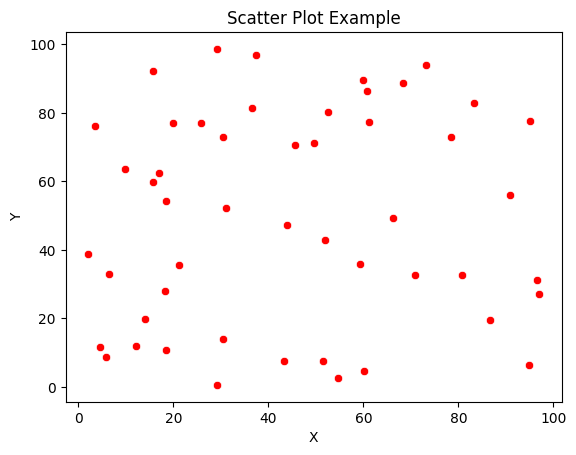

In [518]:
#2 Scatter



np.random.seed(42)
df = pd.DataFrame({"X": np.random.rand(50) * 100, "Y": np.random.rand(50) * 100})


sns.scatterplot(data=df, x="X", y="Y", color="red")
plt.title("Scatter Plot Example")
plt.show()


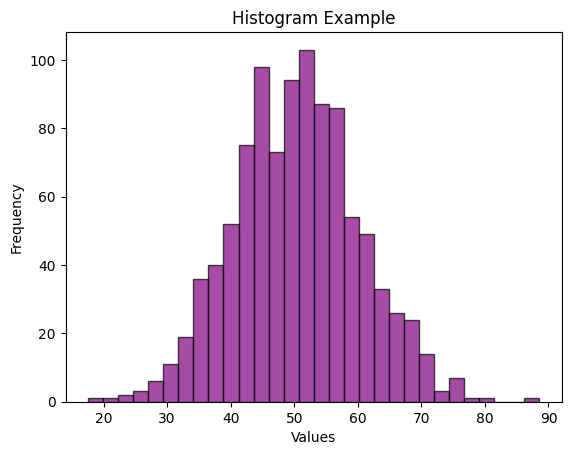

In [519]:
#3 Histogram

data = np.random.normal(loc=50, scale=10, size=1000)


plt.hist(data, bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Histogram Example")
plt.show()


<ipython-input-520-69e82664bf2c>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Y", palette="Set2")


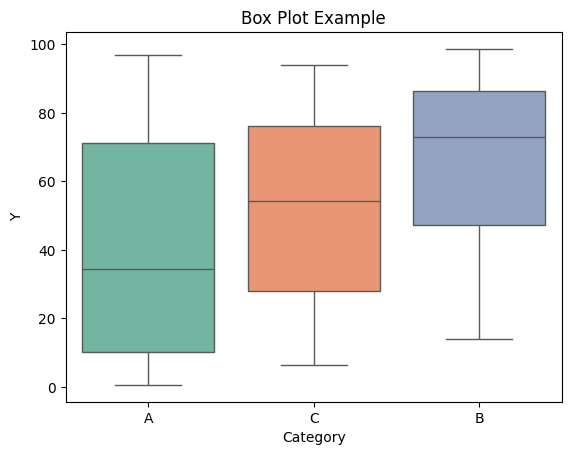

In [520]:
#4 Box Plot
df["Category"] = np.random.choice(["A", "B", "C"], size=50)



sns.boxplot(data=df, x="Category", y="Y", palette="Set2")
plt.title("Box Plot Example")
plt.show()


In [521]:
#5 line chart
import plotly.express as px

df = pd.DataFrame({"Day": range(1, 31), "Sales": np.random.randint(100, 500, size=30)})


fig = px.line(df, x="Day", y="Sales", title="Line Chart Example")
fig.show()
